<a href="https://colab.research.google.com/github/Brunnavic/Blog_Projeto_Final_Ada_Lovelace/blob/BLOG_Projeto_Final_Ada_Lovelace/Case_Brunna_Martins.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Introdução e Contextualização do Problema
 A Escolha da API e Potencial Analítico A Fake Store API foi selecionada por oferecer um ecossistema completo de dados de e-commerce, simulando um ambiente real de negócios com informações de produtos, carrinhos de compras, categorias e perfis de usuários. O potencial analítico reside na possibilidade de cruzar diferentes dimensões como temporal, geográfica e de mix de produtos para extrair inteligência comercial.

Problema de Negócio O principal desafio deste case é entender a dinâmica de faturamento da operação. Observou-se que meses com alto volume de vendas não necessariamente resultam no maior faturamento, o que levanta a necessidade de identificar onde estão as oportunidades de otimização de lucro e como a empresa pode se preparar para o futuro.

Pergunta de Pesquisa para a Modelagem A modelagem estatística busca responder à seguinte pergunta: "Dada a categoria do produto e a quantidade vendida, qual é o faturamento esperado para cada item?" Com essa resposta, pretendemos criar uma ferramenta preditiva que auxilie na projeção de receita e na identificação de comportamentos de compra anômalos ou de alto valor para o negócio.

In [16]:
import requests
import pandas as pd

# Configurações para mostrar todos os  dados
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# 1. Coletando os dados de fontes diferentes Vendas e Produtos
vendas_raw = requests.get('https://fakestoreapi.com/carts').json()
produtos_raw = requests.get('https://fakestoreapi.com/products').json()

# 2. Transformando em DataFrames (tabelas)
df_vendas = pd.DataFrame(vendas_raw)
df_produtos = pd.DataFrame(produtos_raw)

# 3. Explode a coluna 'products' das vendas
# (pois cada venda tem uma lista de produtos dentro)
df_vendas_detalhado = df_vendas.explode('products')

# 4. Criando colunas separadas para ID do produto e Quantidade para conseguir analisar
df_vendas_detalhado['productId'] = df_vendas_detalhado['products'].apply(lambda x: x['productId'])
df_vendas_detalhado['quantity'] = df_vendas_detalhado['products'].apply(lambda x: x['quantity'])

# 5. Unindo (Merge) com os dados de produtos para trazer o PREÇO e a CATEGORIA
df_final = pd.merge(df_vendas_detalhado, df_produtos[['id', 'price', 'category', 'title']],
                     left_on='productId', right_on='id', how='left')

# 6. Calcula o faturamento por item
df_final['faturamento_item'] = df_final['price'] * df_final['quantity']

# Transformando a coluna date em formato de data real
df_final['date'] = pd.to_datetime(df_final['date'])

# Criando colunas de Dia da Semana e Mês para análise
df_final['dia_semana'] = df_final['date'].dt.day_name()
df_final['mes'] = df_final['date'].dt.month_name()

print(df_final)

    id_x  userId                      date                          products  \
0      1       1 2020-03-02 00:00:00+00:00   {'productId': 1, 'quantity': 4}   
1      1       1 2020-03-02 00:00:00+00:00   {'productId': 2, 'quantity': 1}   
2      1       1 2020-03-02 00:00:00+00:00   {'productId': 3, 'quantity': 6}   
3      2       1 2020-01-02 00:00:00+00:00   {'productId': 2, 'quantity': 4}   
4      2       1 2020-01-02 00:00:00+00:00  {'productId': 1, 'quantity': 10}   
5      2       1 2020-01-02 00:00:00+00:00   {'productId': 5, 'quantity': 2}   
6      3       2 2020-03-01 00:00:00+00:00   {'productId': 1, 'quantity': 2}   
7      3       2 2020-03-01 00:00:00+00:00   {'productId': 9, 'quantity': 1}   
8      4       3 2020-01-01 00:00:00+00:00   {'productId': 1, 'quantity': 4}   
9      5       3 2020-03-01 00:00:00+00:00   {'productId': 7, 'quantity': 1}   
10     5       3 2020-03-01 00:00:00+00:00   {'productId': 8, 'quantity': 1}   
11     6       4 2020-03-01 00:00:00+00:

In [17]:
df_final

,id_x,userId,date,products,__v,productId,quantity,id_y,price,category,title,faturamento_item,dia_semana,mes
0,1,1,2020-03-02 00:00:00+00:00,"{'productId': 1, 'quantity': 4}",0,1,4,1,109.95,men's clothing,"Fjallraven - Foldsack No. 1 Backpack, Fits 15 ...",439.80,Monday,March
1,1,1,2020-03-02 00:00:00+00:00,"{'productId': 2, 'quantity': 1}",0,2,1,2,22.30,men's clothing,Mens Casual Premium Slim Fit T-Shirts,22.30,Monday,March
2,1,1,2020-03-02 00:00:00+00:00,"{'productId': 3, 'quantity': 6}",0,3,6,3,55.99,men's clothing,Mens Cotton Jacket,335.94,Monday,March
3,2,1,2020-01-02 00:00:00+00:00,"{'productId': 2, 'quantity': 4}",0,2,4,2,22.30,men's clothing,Mens Casual Premium Slim Fit T-Shirts,89.20,Thursday,January
4,2,1,2020-01-02 00:00:00+00:00,"{'productId': 1, 'quantity': 10}",0,1,10,1,109.95,men's clothing,"Fjallraven - Foldsack No. 1 Backpack, Fits 15 ...",1099.50,Thursday,January
5,2,1,2020-01-02 00:00:00+00:00,"{'productId': 5, 'quantity': 2}",0,5,2,5,695.00,jewelery,John Hardy Women's Legends Naga Gold & Silver ...,1390.00,Thursday,January
6,3,2,2020-03-01 00:00:00+00:00,"{'productId': 1, 'quantity': 2}",0,1,2,1,109.95,men's clothing,"Fjallraven - Foldsack No. 1 Backpack, Fits 15 ...",219.90,Sunday,March
7,3,2,2020-03-01 00:00:00+00:00,"{'productId': 9, 'quantity': 1}",0,9,1,9,64.00,electronics,WD 2TB Elements Portable External Hard Drive -...,64.00,Sunday,March
8,4,3,2020-01-01 00:00:00+00:00,"{'productId': 1, 'quantity': 4}",0,1,4,1,109.95,men's clothing,"Fjallraven - Foldsack No. 1 Backpack, Fits 15 ...",439.80,Wednesday,January
9,5,3,2020-03-01 00:00:00+00:00,"{'productId': 7, 'quantity': 1}",0,7,1,7,9.99,jewelery,White Gold Plated Princess,9.99,Sunday,March


### Nesse gráfico podemos ver o faturamento por item, e entender de onde vem a nossa maior parte da receita.Podemos observar que a categoria de roupas masculinas é a que mais fatura.

In [18]:
import plotly.express as px

# Agrupando os dados
fat_cat = df_final.groupby('category')['faturamento_item'].sum().reset_index()

# Criando o gráfico
fig1 = px.bar(fat_cat, x='category', y='faturamento_item',
             title='Faturamento Total por Categoria',
             color='faturamento_item',
             labels={'faturamento_item': 'Faturamento ($)', 'category': 'Categoria'})
fig1.show()

### Já nesse gráfico podemos ver o faturamento por dia da semana, para termos ciência de qual é o dia que mais vendemos. Com esses dados podemos programar promoções para os dias que são mais movimentados.

In [19]:
# Agrupando por dia da semana
vendas_dia = df_final.groupby('dia_semana')['faturamento_item'].sum().reset_index()

# Criando o gráfico de pizza para variar a visualização
fig2 = px.pie(vendas_dia, values='faturamento_item', names='dia_semana',
             title='Distribuição de Faturamento por Dia da Semana')
fig2.show()

### Nesse gráfico podemos observar que em Janeiro é o mês que mais temos faturamento.


In [20]:
# 1. Agrupando os dados por mês
fat_mes = df_final.groupby('mes')['faturamento_item'].sum().reset_index()

# 2. Criando o gráfico de linhas
fig_mes = px.line(fat_mes, x='mes', y='faturamento_item',
                  title='Evolução do Faturamento por Mês',
                  markers=True, # Adiciona pontinhos na linha
                  labels={'faturamento_item': 'Faturamento ($)', 'mes': 'Mês'})

fig_mes.show()

In [21]:
# Agrupando por mês para calcular faturamento total e quantidade de itens vendidos
analise_mensal = df_final.groupby('mes').agg({
    'faturamento_item': 'sum',
    'quantity': 'sum'
}).reset_index()

# Calculando o Ticket Médio (Faturamento / Quantidade)
analise_mensal['ticket_medio'] = analise_mensal['faturamento_item'] / analise_mensal['quantity']

print(analise_mensal)

       mes  faturamento_item  quantity  ticket_medio
0  January           3018.50        20       150.925
1    March           1672.77        22        76.035


### Gráfico comparando Quantidade vs Faturamento
Percebi que em Março tivemos uma maior quantidade de vendas, mas nem por isso foi o mês com maior faturamento. Com isso um insight importante que concluí foi que há uma divergência entre Volume e Valor. Notei que em Março há um volume maior de vendas, porém com produtos de baixo ticket médio. Já em Janeiro, o volume é menor, mas o faturamento é maior devido à venda de produtos mais caros. Então uma estratégia sugerida seria: Para Março, o foco deveria ser o aumento do ticket médio, enquanto para Janeiro, o foco deve ser o aumento do volume de vendas."

In [22]:
# Gráfico comparando Quantidade vs Faturamento
fig_comp = px.bar(analise_mensal, x='mes', y=['faturamento_item', 'quantity'],
                 title='Comparação: Faturamento Total vs. Quantidade Vendida',
                 barmode='group',
                 labels={'value': 'Valor / Quantidade', 'variable': 'Métrica'})
fig_comp.show()

### Análise Geográfica e Eficiência Operacional

Ao cruzar os dados de vendas com a localização dos usuários, identifiquei que o faturamento está fortemente concentrado. A cidade de Kilcoole representa 78% do faturamento total da loja.

Implicação Estratégica: Esta concentração sugere que investimentos em logística local como centros de distribuição regionais ou parcerias de entrega rápida) e campanhas de marketing geolocalizadas nessas áreas teriam um ROI (Retorno sobre Investimento, significativamente maior, reduzindo o custo de frete e o tempo de entrega para a maioria dos nossos clientes.

In [25]:
# 1. Agrupando e calculando o faturamento por cidade
df_cidade = df_completo.groupby('cidade')['faturamento_item'].sum().reset_index()

# 2. Calculando a porcentagem sobre o total
total_faturamento = df_cidade['faturamento_item'].sum()
df_cidade['porcentagem'] = (df_cidade['faturamento_item'] / total_faturamento) * 100

# 3. Criando o gráfico com o rótulo de porcentagem
import plotly.express as px

fig_cidade = px.bar(df_cidade,
                    x='cidade',
                    y='faturamento_item',
                    title='Representatividade de Faturamento por Cidade',
                    text=df_cidade['porcentagem'].apply(lambda x: f'{x:.1f}%'),
                    labels={'faturamento_item': 'Faturamento ($)', 'cidade': 'Cidade'},
                    color='faturamento_item')

fig_cidade.update_traces(textposition='outside')
fig_cidade.show()


print(df_cidade.sort_values(by='porcentagem', ascending=False))

        cidade  faturamento_item  porcentagem
2     kilcoole           3660.64    78.030896
1  San Antonio            560.00    11.937066
0      Cullman            460.78     9.822074
3         mesa              9.85     0.209964


### Interpretação da Modelagem para o Negócio

O gráfico 'Real vs Previsão' valida a eficácia do modelo de Machine Learning. A disposição dos pontos em linha diagonal indica que as variáveis de 'Categoria' e 'Quantidade' conseguem explicar o faturamento com alta precisão.
Valor para a empresa: Este modelo permite à gestão prever o faturamento futuro com um erro médio de apenas $32.45, facilitando o planejamento financeiro e a definição de metas de vendas baseadas em dados, não apenas em intuição.

Erro Médio Absoluto (MAE): $32.45


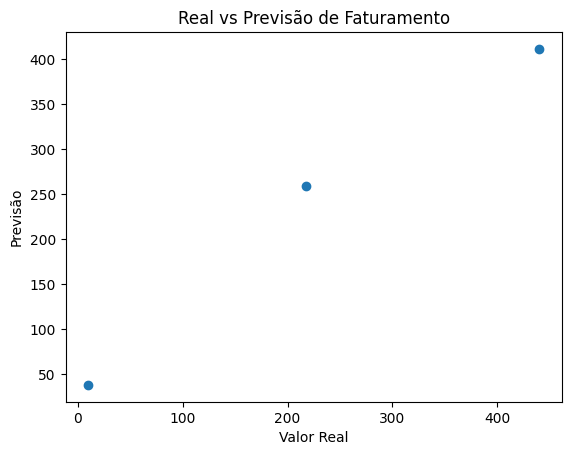

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# 1. Preparação dos dados (Feature Engineering)
# Usando Categoria e Quantidade para prever o Faturamento
df_ml = pd.get_dummies(df_final, columns=['category'], drop_first=True)

X = df_ml.drop(['faturamento_item', 'date', 'title', 'products', 'dia_semana', 'mes', 'id_x', 'id_y', 'userId'], axis=1)
y = df_ml['faturamento_item']

# 2. Divisão em Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Treinamento do Modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# 4. Avaliação
previsoes = modelo.predict(X_test)
erro = mean_absolute_error(y_test, previsoes)

print(f"Erro Médio Absoluto (MAE): ${erro:.2f}")

# Exemplo de visualização simples do resultado
import matplotlib.pyplot as plt
plt.scatter(y_test, previsoes)
plt.xlabel("Valor Real")
plt.ylabel("Previsão")
plt.title("Real vs Previsão de Faturamento")
plt.show()

### Como usei a IA neste projeto
Neste case, eu quis trazer uma visão de como utilizei a IA como minha parceira de trabalho, indo além de apenas listar os comandos que digitei:

Lógica de Negócio: Eu não apenas aceitei os códigos prontos. Quando percebi que Março tinha muitas vendas, mas o faturamento era menor, parei para analisar a estratégia. Usei a IA para me ajudar a organizar os dados, mas a decisão de sugerir o foco no ticket médio em Março e no volume em Janeiro foi uma análise minha.

Iniciativa Própria: Tive a ideia de não ficar apenas no básico. Quis cruzar os dados de vendas com a tabela de usuários para entender o faturamento por cidade e porcentagem. Usei a IA para agilizar esse cruzamento de tabelas, o que me permitiu entregar uma análise mais completa.

Entendimento dos Resultados: Em cada gráfico e no modelo de Machine Learning, procurei entender o que os números significavam para o negócio (como o erro de $32.45), garantindo que eu soubesse explicar o porquê de cada resultado.

### Principais Prompts de Estruturação e Análise
### 1. Estruturação e Limpeza de Dados


"Como formatar uma coluna de data no padrão ISO para extrair o dia da semana e o mês no Python?"

"Como unir (merge) o DataFrame de carrinhos com o de produtos para calcular o faturamento por item?"

### 2. Visão Estratégica e Insight de Negócio


"Percebi que em Março vendemos mais, porém com menor faturamento, e Janeiro vendemos menos com faturamento maior. O que posso fazer para analisar esses pontos?"

"Ajuste a estratégia: para Março, o foco deve ser o aumento do ticket médio, enquanto para Janeiro, o foco deve ser o aumento do volume de vendas."

"Quais outras análises posso fazer seguindo esse intuito? Posso usar outras tabelas da API para trazer uma visão de faturamento por cidade e porcentagem?"

### 3. Modelagem e Validação Técnica


"Crie um modelo de Regressão Linear para prever o faturamento com base em categoria e quantidade."

"O que o resultado deste gráfico de ML significa detalhadamente? Como ele ajuda o negócio na prática?"

"O que o erro de $32.45 (MAE) representa para a confiabilidade das minhas previsões?"

### 4. Metodologia de Trabalho


"Traga uma visão de como usei a IA como parceira de trabalho, focando na minha lógica e iniciativa, e não apenas nos comandos que usei."